In [73]:
import pandas as pd
import mne
from mne.decoding import CSP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

## Import filter Data

In [74]:
final_df = pd.read_csv("dataset/eeg_features.csv")

freq_bands = {
    "Delta": ["Delta"],
    "Theta": ["Theta"],
    "Alpha": ["Alpha"],
    "Beta": ["Beta"],
    "Gamma": ["Gamma"]
}

## Classification Between Alzheimer Disease Group and Healthy Group

In [75]:
# classification between "0":"Alzheimer Disease Group" and "2": "Healthy Group"
A_C_df = final_df[final_df["Label"].isin([0, 2])]

In [76]:
X = A_C_df.drop(columns=["Label"])
y = A_C_df["Label"].values

# Replace Label=2 with 1 
y[y == 2] = 1

#### Extract CSP feature and LDA Classification

In [77]:
band_accuracies = {}

for band_name, band_features in freq_bands.items():
    print(f"\n=== Processing {band_name} Band ===")

    # Select features of the current frequency band
    selected_columns = [col for col in X.columns if any(b in col for b in band_features)]
    X_band = X[selected_columns].values

    X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data to (trials, channels, samples)
    num_trials_train, num_channels = X_train.shape
    X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
    X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

    # CSP feature extraction
    csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
    X_test_csp = csp.transform(X_test_reshaped)

    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_csp, y_train)

    y_pred = clf.predict(X_test_csp)

    accuracy = accuracy_score(y_test, y_pred)
    band_accuracies[band_name] = accuracy

    print(f"A vs C: CSP + LDA Accuracy ({band_name} Band): {accuracy:.4f}")
    print(classification_report(y_test, y_pred))



=== Processing Delta Band ===
Computing rank from data with rank=None


    Using tolerance 1.3 (2.2e-16 eps * 19 dim * 3.1e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
A vs C: CSP + LDA Accuracy (Delta Band): 0.5821
              precision    recall  f1-score   support

           0       0.60      0.77      0.67       850
           1       0.55      0.35      0.43       684

    accuracy                           0.58      1534
   macro avg       0.57      0.56      0.55      1534
weighted avg       0.57      0.58      0.56      1534


=== Processing Theta Band ===
Computing rank from data with rank=None
    Using tolerance 1.3 (2.2e-16 eps * 19 dim * 3.2e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using 

In [78]:
best_band = max(band_accuracies, key=band_accuracies.get)

print("Frequency Band Accuracy Comparison")
for band, acc in band_accuracies.items():
    print(f"{band} Band: {acc:.4f}")

print(f"The best EEG frequency band is {best_band}, with an accuracy of {band_accuracies[best_band]:.4f}")

Frequency Band Accuracy Comparison
Delta Band: 0.5821
Theta Band: 0.6701
Alpha Band: 0.7432
Beta Band: 0.7164
Gamma Band: 0.6701
The best EEG frequency band is Alpha, with an accuracy of 0.7432


In [79]:
A_C_alpha_lda_acc = band_accuracies["Alpha"]

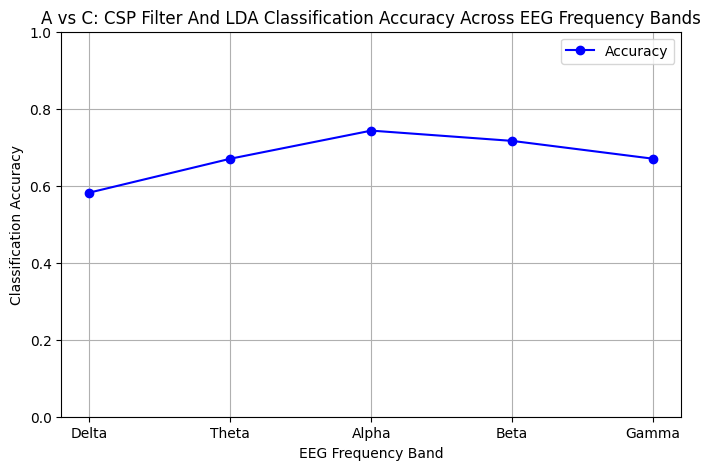

In [80]:
# Find the best frequency band
best_band = max(band_accuracies, key=band_accuracies.get)

# Plot classification accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(list(band_accuracies.keys()), list(band_accuracies.values()), marker='o', linestyle='-', color='b', label="Accuracy")
plt.xlabel("EEG Frequency Band")
plt.ylabel("Classification Accuracy")
plt.title("A vs C: CSP Filter And LDA Classification Accuracy Across EEG Frequency Bands")
plt.ylim(0, 1) 
plt.grid(True)
plt.legend()
plt.show()

## Classification between Frontotemporal Dementia Group and Healthy Group

In [81]:
# classification between "1":"Frontotemporal Dementia Group" and "2": "Healthy Group"
F_C_df = final_df[final_df["Label"].isin([1, 2])]

In [82]:
X = F_C_df.drop(columns=["Label"])
y = F_C_df["Label"].values

# Replace Label=1 with 0
y[y == 1] = 0

# Replace Label=2 with 1 
y[y == 2] = 1

In [ ]:
band_accuracies = {}

for band_name, band_features in freq_bands.items():
    print(f"\n=== Processing {band_name} Band ===")

    # Select features of the current frequency band
    selected_columns = [col for col in X.columns if any(b in col for b in band_features)]
    X_band = X[selected_columns].values

    X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data to (trials, channels, samples)
    num_trials_train, num_channels = X_train.shape
    X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
    X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

    # CSP feature extraction
    csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
    X_test_csp = csp.transform(X_test_reshaped)

    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_csp, y_train)

    y_pred = clf.predict(X_train_csp)

    accuracy = accuracy_score(y_train, y_pred)
    band_accuracies[band_name] = accuracy

    print(f"F vs C: CSP + LDA Accuracy ({band_name} Band): {accuracy:.4f}")
    print(classification_report(y_train, y_pred))


=== Processing Delta Band ===
Computing rank from data with rank=None
    Using tolerance 1.1 (2.2e-16 eps * 19 dim * 2.6e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
F vs C: CSP + LDA Accuracy (Delta Band): 0.5790
              precision    recall  f1-score   support

           0       0.54      0.31      0.40       543
           1       0.59      0.79      0.68       685

    accuracy                           0.58      1228
   macro avg       0.57      0.55      0.54      1228
weighted avg       0.57      0.58      0.55      1228


=== Processing Theta Band ===
Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.9e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projector

In [84]:
# **Find the Best Frequency Band**
best_band = max(band_accuracies, key=band_accuracies.get)
print("Frequency Band Accuracy Comparison")
for band, acc in band_accuracies.items():
    print(f"{band} Band: {acc:.4f}")

print(f"The best EEG frequency band is {best_band}, with an accuracy of {band_accuracies[best_band]:.4f}")

Frequency Band Accuracy Comparison
Delta Band: 0.5790
Theta Band: 0.6319
Alpha Band: 0.7077
Beta Band: 0.7419
Gamma Band: 0.7533
The best EEG frequency band is Gamma, with an accuracy of 0.7533


In [85]:
F_C_gamma_lda_acc = band_accuracies["Gamma"]

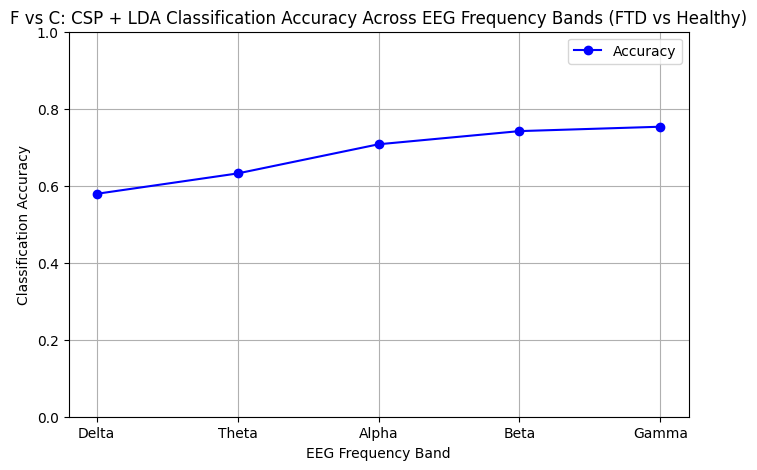

In [86]:
# **Plot Classification Accuracy Across Frequency Bands**
plt.figure(figsize=(8, 5))
plt.plot(list(band_accuracies.keys()), list(band_accuracies.values()), marker='o', linestyle='-', color='b', label="Accuracy")
plt.xlabel("EEG Frequency Band")
plt.ylabel("Classification Accuracy")
plt.title("F vs C: CSP + LDA Classification Accuracy Across EEG Frequency Bands (FTD vs Healthy)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

## Classification between Alzheimer Disease Group and Frontotemporal Dementia Group

In [87]:
# classification between "0":"Alzheimer Disease Group" and "1":"Frontotemporal Dementia Group"
A_F_df = final_df[final_df["Label"].isin([0, 1])]

In [88]:
X = A_F_df.drop(columns=["Label"])
y = A_F_df["Label"].values

In [89]:
band_accuracies = {}

for band_name, band_features in freq_bands.items():
    print(f"\n=== Processing {band_name} Band ===")

    # Select features of the current frequency band
    selected_columns = [col for col in X.columns if any(b in col for b in band_features)]
    X_band = X[selected_columns].values

    X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

    # Normalize data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Reshape data to (trials, channels, samples)
    num_trials_train, num_channels = X_train.shape
    X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
    X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

    # CSP feature extraction
    csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
    X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
    X_test_csp = csp.transform(X_test_reshaped)

    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train_csp, y_train)

    y_pred = clf.predict(X_test_csp)

    accuracy = accuracy_score(y_test, y_pred)
    band_accuracies[band_name] = accuracy

    print(f"A vs F: CSP + LDA Accuracy ({band_name} Band): {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


=== Processing Delta Band ===
Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.7e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
A vs F: CSP + LDA Accuracy (Delta Band): 0.6375
              precision    recall  f1-score   support

           0       0.64      0.91      0.75       850
           1       0.60      0.21      0.31       543

    accuracy                           0.64      1393
   macro avg       0.62      0.56      0.53      1393
weighted avg       0.63      0.64      0.58      1393


=== Processing Theta Band ===
Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.8e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projector

In [90]:
# **Find the Best Frequency Band**
best_band = max(band_accuracies, key=band_accuracies.get)
print("Frequency Band Accuracy Comparison")
for band, acc in band_accuracies.items():
    print(f"{band} Band: {acc:.4f}")

print(f"The best EEG frequency band is {best_band}, with an accuracy of {band_accuracies[best_band]:.4f}")

Frequency Band Accuracy Comparison
Delta Band: 0.6375
Theta Band: 0.6159
Alpha Band: 0.6597
Beta Band: 0.6762
Gamma Band: 0.6935
The best EEG frequency band is Gamma, with an accuracy of 0.6935


In [91]:
A_F_gamma_lda_acc = band_accuracies["Gamma"]

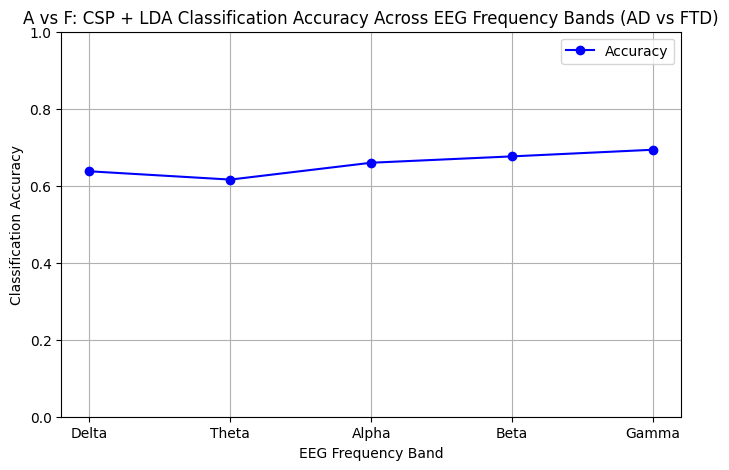

In [92]:
plt.figure(figsize=(8, 5))
plt.plot(list(band_accuracies.keys()), list(band_accuracies.values()), marker='o', linestyle='-', color='b', label="Accuracy")
plt.xlabel("EEG Frequency Band")
plt.ylabel("Classification Accuracy")
plt.title("A vs F: CSP + LDA Classification Accuracy Across EEG Frequency Bands (AD vs FTD)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

## Classification Alzheimer Disease Group and Healthy Group with Only Alpha Band

#### Model - Decision Tree

In [93]:
X = A_C_df.drop(columns=["Label"])
y = A_C_df["Label"].values

# classification between "0":"Alzheimer Disease Group" and "2": "Healthy Group"
alpha_band = "Alpha"

# Select features for the Alpha Band
selected_columns = [col for col in X.columns if any(b in col for b in freq_bands[alpha_band])]
X_band = X[selected_columns].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data to (trials, channels, samples)
num_trials_train, num_channels = X_train.shape
X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

# CSP Feature Extraction
csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
X_test_csp = csp.transform(X_test_reshaped)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_csp, y_train)

# Make Predictions
y_pred = clf.predict(X_test_csp)

# Evaluate Model
A_C_decision_accuracy = accuracy_score(y_test, y_pred)
print(f"A vs C: CSP + Decision Tree Accuracy (Alpha Band): {A_C_decision_accuracy:.4f}")
print(classification_report(y_test, y_pred))

Computing rank from data with rank=None
    Using tolerance 1.3 (2.2e-16 eps * 19 dim * 3e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
A vs C: CSP + Decision Tree Accuracy (Alpha Band): 0.7073
              precision    recall  f1-score   support

           0       0.75      0.71      0.73       850
           1       0.66      0.71      0.68       684

    accuracy                           0.71      1534
   macro avg       0.71      0.71      0.71      1534
weighted avg       0.71      0.71      0.71      1534



#### Model - Random Forest

In [94]:
# Train Random Forest Classifier
clf_random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
clf_random_forest.fit(X_train_csp, y_train)

# Make Predictions
y_pred = clf_random_forest.predict(X_test_csp)

# Evaluate Model
A_C_RF_accuracy = accuracy_score(y_test, y_pred)
print(f"A vs C: CSP + Random Forest Accuracy (Alpha Band): {A_C_RF_accuracy :.4f}")
print(classification_report(y_test, y_pred))

A vs C: CSP + Random Forest Accuracy (Alpha Band): 0.8090
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       850
           1       0.83      0.72      0.77       684

    accuracy                           0.81      1534
   macro avg       0.81      0.80      0.80      1534
weighted avg       0.81      0.81      0.81      1534



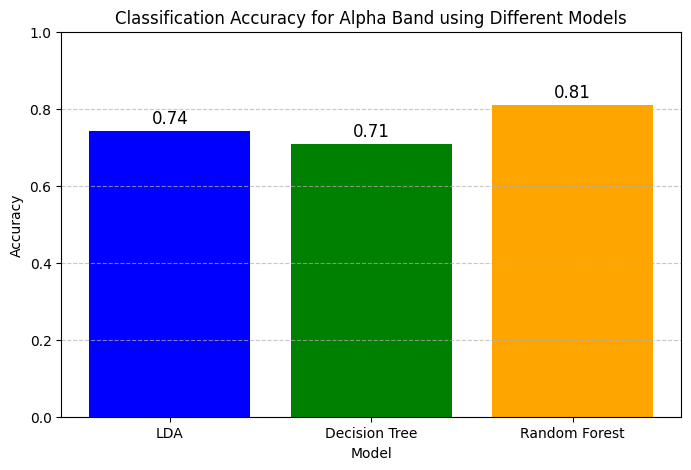

In [95]:
A_C_model_accuracies = {
    "LDA": A_C_alpha_lda_acc,
    "Decision Tree": A_C_decision_accuracy,
    "Random Forest": A_C_RF_accuracy,
}

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(A_C_model_accuracies.keys(), A_C_model_accuracies.values(), color=['blue', 'green', 'orange'])

# Add title and labels
plt.title("Classification Accuracy for Alpha Band using Different Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show accuracy values on top of bars
for i, acc in enumerate(A_C_model_accuracies.values()):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)

# Show the plot
plt.show()

## Classification between Frontotemporal Dementia Group and Healthy Group with Only Gamma Band

#### Model - Decision Tree

In [96]:
X = F_C_df.drop(columns=["Label"])
y = F_C_df["Label"].values

alpha_band = "Gamma"

# Select features for the Alpha Band
selected_columns = [col for col in X.columns if any(b in col for b in freq_bands[alpha_band])]
X_band = X[selected_columns].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data to (trials, channels, samples)
num_trials_train, num_channels = X_train.shape
X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

# CSP Feature Extraction
csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
X_test_csp = csp.transform(X_test_reshaped)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_csp, y_train)

# Make Predictions
y_pred = clf.predict(X_test_csp)

# Evaluate Model
F_C_decision_accuracy = accuracy_score(y_test, y_pred)
print(f"F vs C: CSP + Decision Tree Accuracy (Gamma Band): {F_C_decision_accuracy:.4f}")
print(classification_report(y_test, y_pred))

Computing rank from data with rank=None


    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.7e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
F vs C: CSP + Decision Tree Accuracy (Gamma Band): 0.8453
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       543
           1       0.86      0.86      0.86       685

    accuracy                           0.85      1228
   macro avg       0.84      0.84      0.84      1228
weighted avg       0.85      0.85      0.85      1228



#### Model - Random Forest

In [97]:
clf_random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
clf_random_forest.fit(X_train_csp, y_train)

# Make Predictions
y_pred = clf_random_forest.predict(X_test_csp)

# Evaluate Model
F_C_RF_accuracy = accuracy_score(y_test, y_pred)
print(f"F vs C: CSP + Random Forest Accuracy (Gamma Band): {F_C_RF_accuracy:.4f}")
print(classification_report(y_test, y_pred))

F vs C: CSP + Random Forest Accuracy (Gamma Band): 0.9243
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       543
           1       0.91      0.95      0.93       685

    accuracy                           0.92      1228
   macro avg       0.93      0.92      0.92      1228
weighted avg       0.92      0.92      0.92      1228



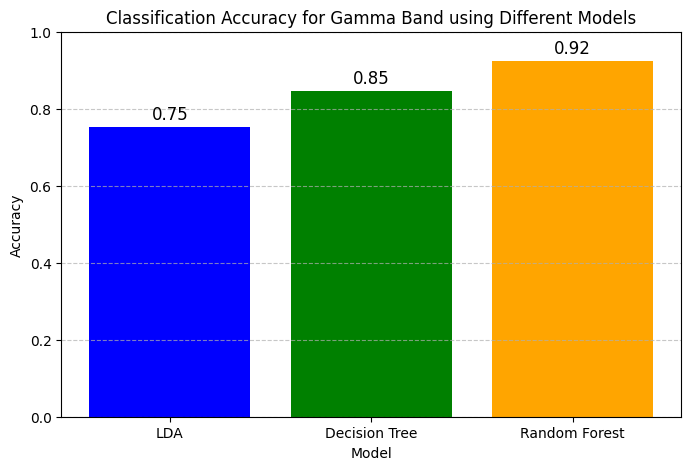

In [98]:
F_C_model_accuracies = {
    "LDA": F_C_gamma_lda_acc,
    "Decision Tree": F_C_decision_accuracy,
    "Random Forest": F_C_RF_accuracy,
}

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(F_C_model_accuracies.keys(), F_C_model_accuracies.values(), color=['blue', 'green', 'orange'])

# Add title and labels
plt.title("Classification Accuracy for Gamma Band using Different Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show accuracy values on top of bars
for i, acc in enumerate(F_C_model_accuracies.values()):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)

# Show the plot
plt.show()

## Classification between Alzheimer Disease Group and Frontotemporal Dementia Group with Only Gamma Band

#### Model - Decision Tree

In [99]:
X = A_F_df.drop(columns=["Label"])
y = A_F_df["Label"].values

alpha_band = "Gamma"

# Select features for the Alpha Band
selected_columns = [col for col in X.columns if any(b in col for b in freq_bands[alpha_band])]
X_band = X[selected_columns].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.2, random_state=42, stratify=y)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data to (trials, channels, samples)
num_trials_train, num_channels = X_train.shape
X_train_reshaped = X_train.reshape(num_trials_train, num_channels, 1)  # Single sample time point
X_test_reshaped = X_test.reshape(X_test.shape[0], num_channels, 1)

# CSP Feature Extraction
csp = CSP(n_components=20, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train_reshaped, y_train)
X_test_csp = csp.transform(X_test_reshaped)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_csp, y_train)

# Make Predictions
y_pred = clf.predict(X_test_csp)

# Evaluate Model
A_F_decision_accuracy = accuracy_score(y_test, y_pred)
print(f"F vs C: CSP + Decision Tree Accuracy (Gamma Band): {A_F_decision_accuracy:.4f}")
print(classification_report(y_test, y_pred))

Computing rank from data with rank=None
    Using tolerance 1.2 (2.2e-16 eps * 19 dim * 2.8e+14  max singular value)
    Estimated rank (data): 19
    data: rank 19 computed from 19 data channels with 0 projectors
Reducing data rank from 19 -> 19
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
F vs C: CSP + Decision Tree Accuracy (Gamma Band): 0.7947
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       850
           1       0.74      0.72      0.73       543

    accuracy                           0.79      1393
   macro avg       0.78      0.78      0.78      1393
weighted avg       0.79      0.79      0.79      1393



#### Model - Random Forest

In [100]:
clf_random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
clf_random_forest.fit(X_train_csp, y_train)

# Make Predictions
y_pred = clf_random_forest.predict(X_test_csp)

# Evaluate Model
A_F_RF_accuracy = accuracy_score(y_test, y_pred)
print(f"F vs C: CSP + Random Forest Accuracy (Gamma Band): {A_F_RF_accuracy:.4f}")
print(classification_report(y_test, y_pred))

F vs C: CSP + Random Forest Accuracy (Gamma Band): 0.8823
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       850
           1       0.92      0.76      0.84       543

    accuracy                           0.88      1393
   macro avg       0.89      0.86      0.87      1393
weighted avg       0.89      0.88      0.88      1393



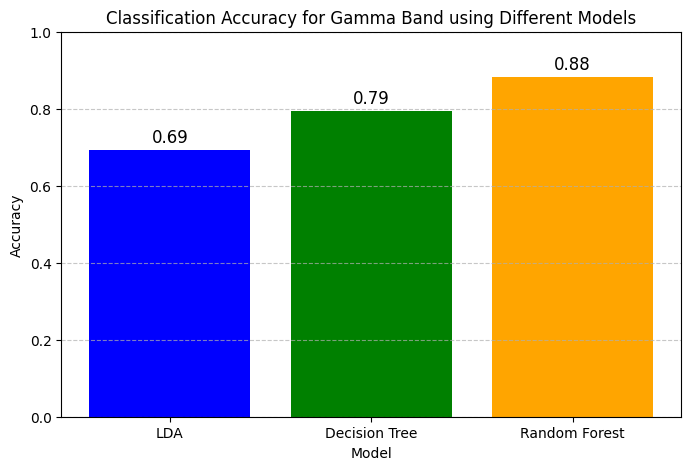

In [101]:
A_F_model_accuracies = {
    "LDA": A_F_gamma_lda_acc,
    "Decision Tree": A_F_decision_accuracy,
    "Random Forest": A_F_RF_accuracy,
}

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(A_F_model_accuracies.keys(), A_F_model_accuracies.values(), color=['blue', 'green', 'orange'])

# Add title and labels
plt.title("Classification Accuracy for Gamma Band using Different Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show accuracy values on top of bars
for i, acc in enumerate(A_F_model_accuracies.values()):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)

# Show the plot
plt.show()